# 03 — Exploratory Data Analysis (EDA)

## Objective
Understand what behavioral patterns, driver characteristics,
and temporal trajectories most strongly predict driver churn —
building the analytical foundation for feature engineering.

## The Core EDA Question
Not: "What is this driver's average ride count?"
But: "Is this driver's ride count going UP or DOWN?"

Trajectory matters more than current value.
A driver doing 20 rides/week who was doing 35 last month
is more at risk than a driver doing 20 rides/week who was
doing 15 last month — even though both show 20 rides today.

## Business Questions We Answer
1. Which driver profile characteristics predict churn?
2. How does weekly ride volume diverge between churned
   and retained drivers over 16 weeks?
3. What is the pre-churn behavioral signature?
   (the weeks before going silent)
4. Do earnings trajectories predict churn better than
   ride count trajectories?
5. Does cancellation rate rise before churn?
6. Do support tickets predict churn and when?
7. Does incentive engagement change before churn?
8. What is the optimal "last active week" distribution?
9. Which combinations of signals are most predictive?
10. What features should Feature Engineering prioritize?

## Two Levels of Analysis
Level 1 — Static: Driver characteristics at a point in time
Level 2 — Dynamic: How behavior changes across 16 weeks
Level 2 is unique to this project and is the most valuable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

CHURN_COLORS = {0: "#4CAF50", 1: "#F44336"}
CHURN_LABELS = {0: "Retained", 1: "Churned"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

drivers_df   = pd.read_csv(PATH + "drivers_clean.csv",
                            parse_dates=["join_date"])
weekly_df    = pd.read_csv(PATH + "weekly_activity_clean.csv",
                            parse_dates=["week_start_date"])
incentive_df = pd.read_csv(PATH + "incentives_clean.csv")
tickets_df   = pd.read_csv(PATH + "support_tickets_clean.csv")

# Attach churn label to weekly data for easy filtering
churn_map = drivers_df.set_index("driver_id")["is_churned"].to_dict()
weekly_df["is_churned"] = weekly_df["driver_id"].map(churn_map)

print("Data loaded ✅")
print(f"  drivers          : {drivers_df.shape}")
print(f"  weekly_activity  : {weekly_df.shape}")
print(f"  incentives       : {incentive_df.shape}")
print(f"  support_tickets  : {tickets_df.shape}")
print(f"\nChurn label attached to weekly data: ✅")
print(f"Churned drivers  : "
      f"{(drivers_df['is_churned']==1).sum():,} "
      f"({drivers_df['is_churned'].mean()*100:.1f}%)")
print(f"Retained drivers : "
      f"{(drivers_df['is_churned']==0).sum():,} "
      f"({(1-drivers_df['is_churned'].mean())*100:.1f}%)")

Data loaded ✅
  drivers          : (5000, 20)
  weekly_activity  : (80000, 18)
  incentives       : (7283, 6)
  support_tickets  : (10028, 6)

Churn label attached to weekly data: ✅
Churned drivers  : 2,015 (40.3%)
Retained drivers : 2,985 (59.7%)


## Section 1 — Static Driver Characteristics

### Question: Which driver profile attributes predict churn?

Before analyzing behavioral trajectories, we understand
which FIXED characteristics (age, experience, vehicle type,
city knowledge) correlate with churn propensity.

These static features will appear in the Feature Engineering
directly from the drivers table — no aggregation needed.

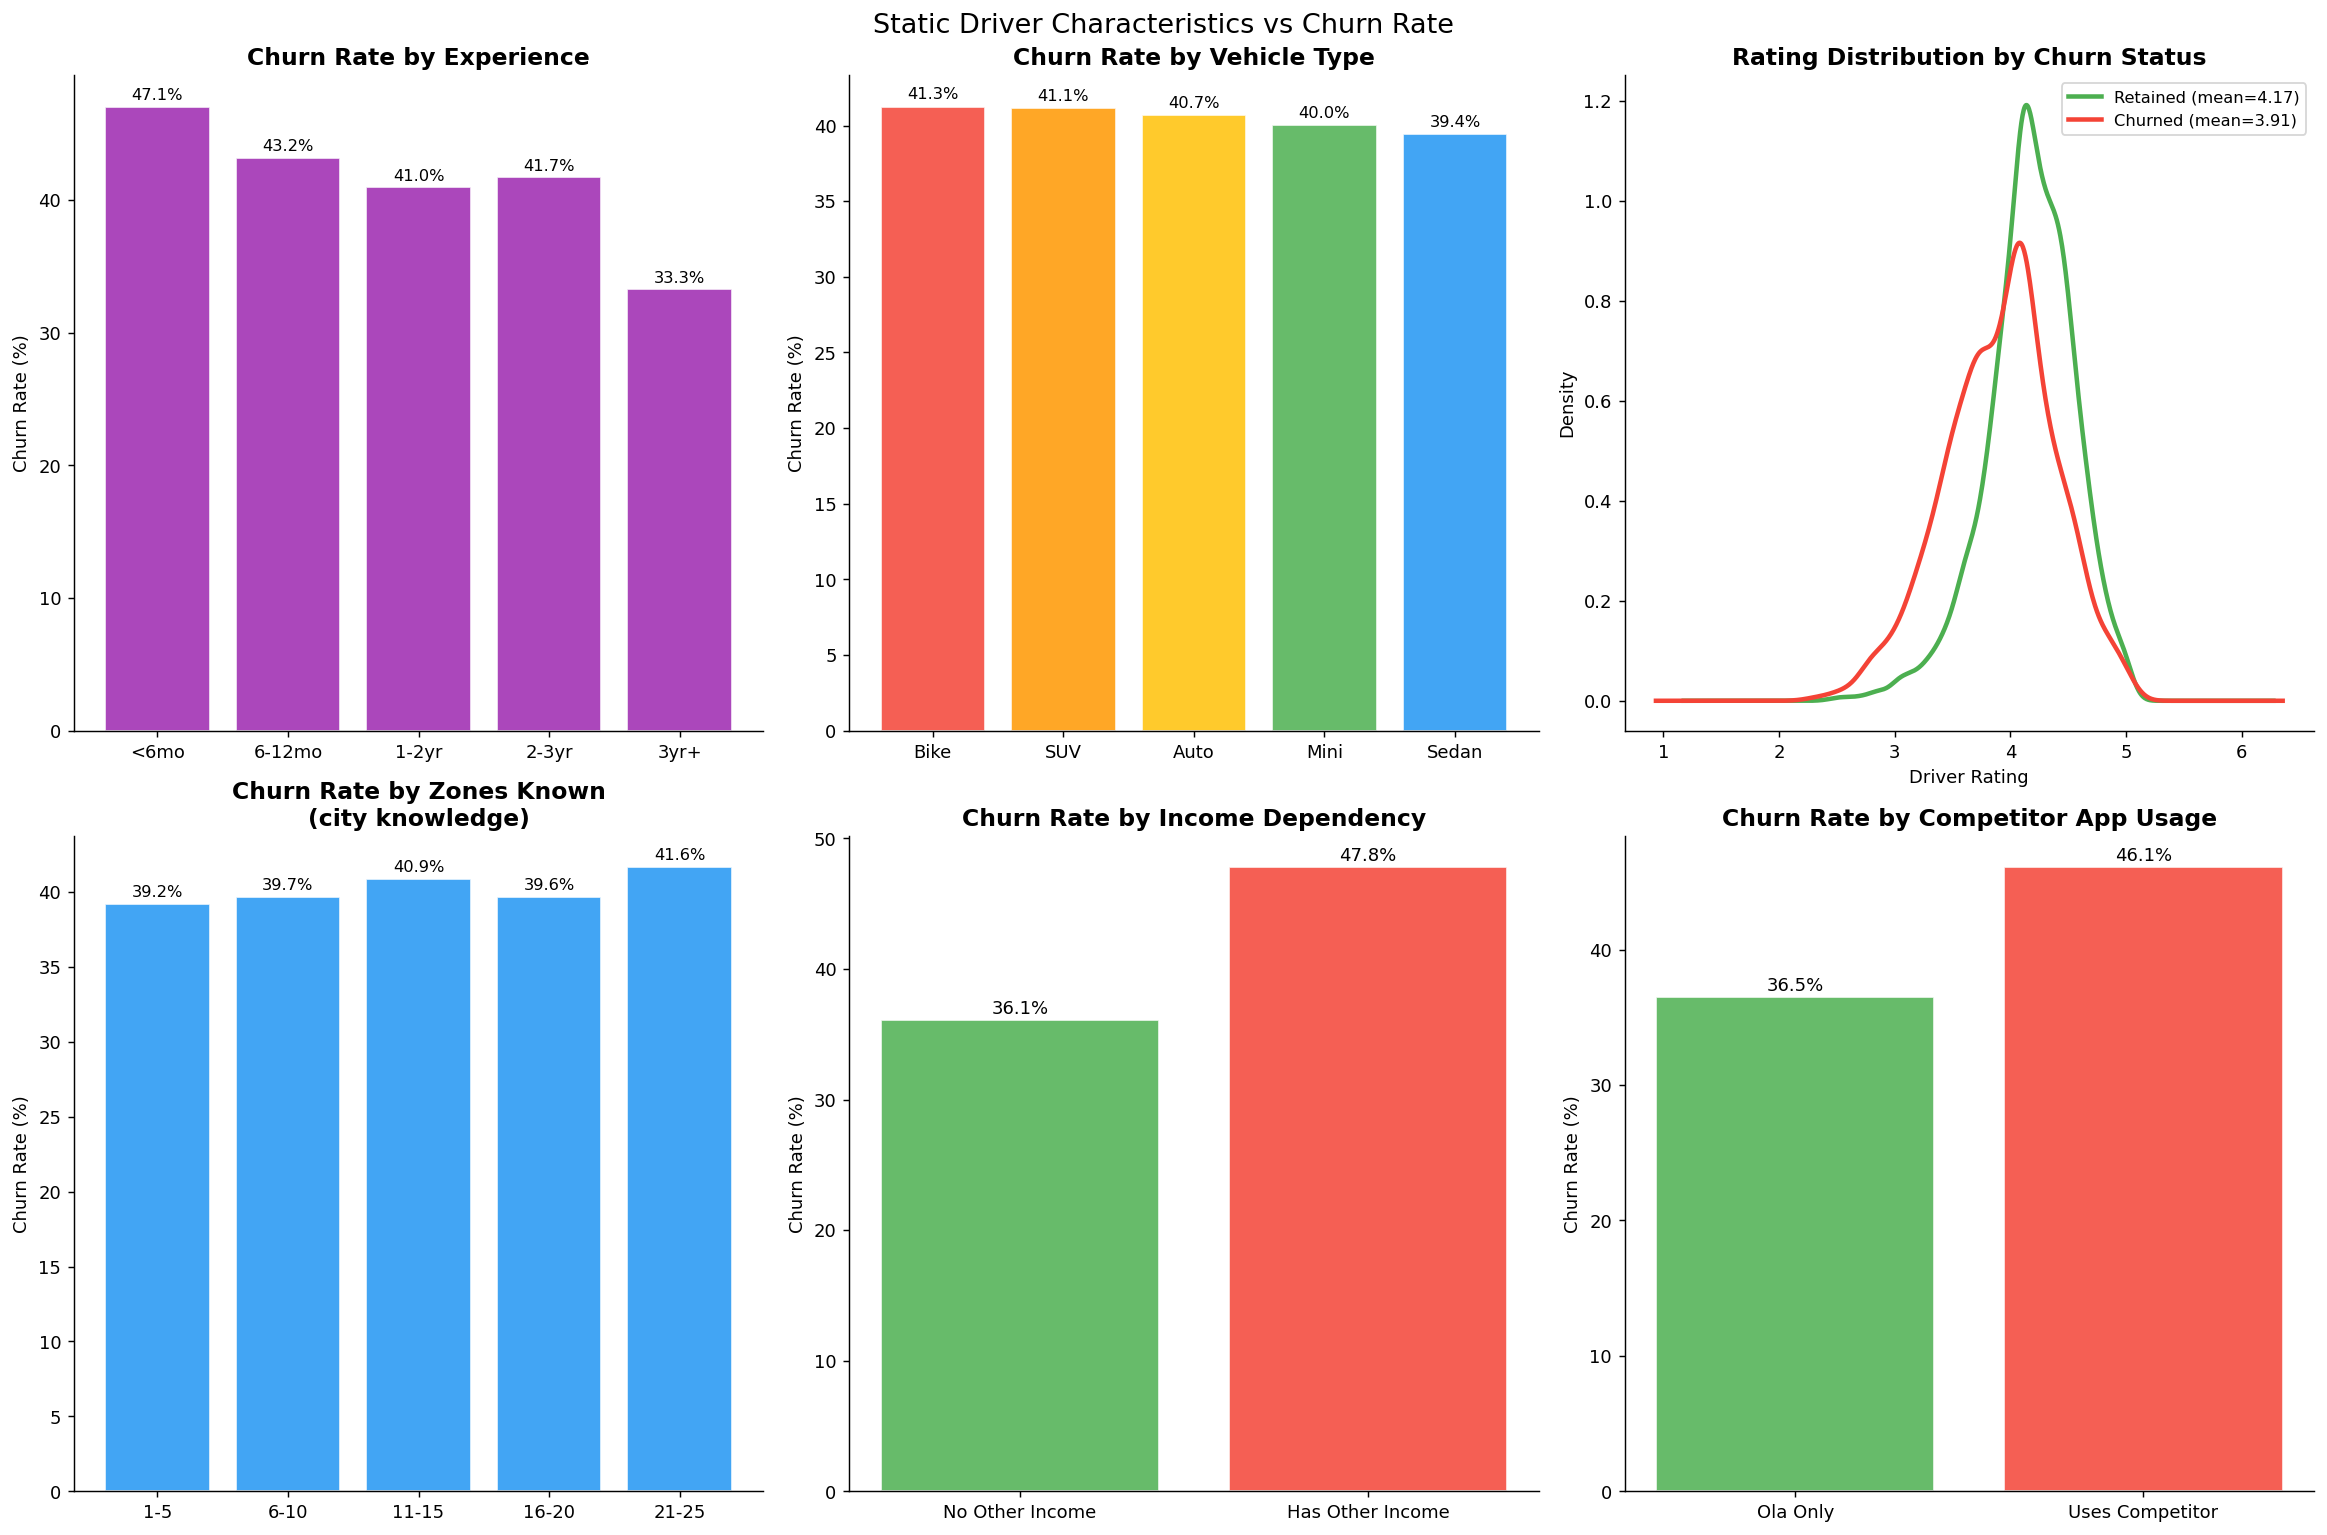

Static characteristic summary:
  Experience effect  : 47.1% (<6mo) vs 33.3% (3yr+)
  Rating difference  : Churned=3.910 Retained=4.169
  Other income lift  : +11.7% churn
  Competitor lift    : +9.6% churn


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Static Driver Characteristics vs Churn Rate",
             fontsize=15)

# ── Experience years ──────────────────────────────────────────
exp_churn = drivers_df.groupby(
    pd.cut(drivers_df["experience_years"],
           bins=[0, 0.5, 1, 2, 3, 10],
           labels=["<6mo","6-12mo","1-2yr","2-3yr","3yr+"])
)["is_churned"].mean() * 100

axes[0][0].bar(exp_churn.index.astype(str),
               exp_churn.values,
               color="#9C27B0", edgecolor="white", alpha=0.85)
axes[0][0].set_title("Churn Rate by Experience")
axes[0][0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(exp_churn.values):
    axes[0][0].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Vehicle type ──────────────────────────────────────────────
vehicle_churn = drivers_df.groupby("vehicle_type")[
    "is_churned"
].mean() * 100
vehicle_churn = vehicle_churn.sort_values(ascending=False)

colors_v = ["#F44336","#FF9800","#FFC107","#4CAF50","#2196F3"]
axes[0][1].bar(vehicle_churn.index, vehicle_churn.values,
               color=colors_v, edgecolor="white", alpha=0.85)
axes[0][1].set_title("Churn Rate by Vehicle Type")
axes[0][1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(vehicle_churn.values):
    axes[0][1].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Rating distribution ───────────────────────────────────────
for k in [0, 1]:
    subset = drivers_df[
        drivers_df["is_churned"] == k
    ]["rating"].dropna()
    subset.plot.kde(
        ax=axes[0][2], color=CHURN_COLORS[k],
        linewidth=2.5, label=f"{CHURN_LABELS[k]} "
                             f"(mean={subset.mean():.2f})"
    )
axes[0][2].set_title("Rating Distribution by Churn Status")
axes[0][2].set_xlabel("Driver Rating")
axes[0][2].set_ylabel("Density")
axes[0][2].legend(fontsize=9)

# ── Zones known ───────────────────────────────────────────────
zone_churn = drivers_df.groupby(
    pd.cut(drivers_df["zones_known"],
           bins=[0, 5, 10, 15, 20, 25],
           labels=["1-5","6-10","11-15","16-20","21-25"])
)["is_churned"].mean() * 100

axes[1][0].bar(zone_churn.index.astype(str),
               zone_churn.values,
               color="#2196F3", edgecolor="white", alpha=0.85)
axes[1][0].set_title("Churn Rate by Zones Known\n"
                     "(city knowledge)")
axes[1][0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(zone_churn.values):
    axes[1][0].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=9)

# ── Other income source ───────────────────────────────────────
income_churn = drivers_df.groupby(
    "has_other_income"
)["is_churned"].mean() * 100
axes[1][1].bar(
    ["No Other Income", "Has Other Income"],
    [income_churn[False], income_churn[True]],
    color=["#4CAF50","#F44336"], edgecolor="white", alpha=0.85
)
axes[1][1].set_title("Churn Rate by Income Dependency")
axes[1][1].set_ylabel("Churn Rate (%)")
for i, v in enumerate([income_churn[False], income_churn[True]]):
    axes[1][1].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=10)

# ── Competitor app usage ──────────────────────────────────────
comp_churn = drivers_df.groupby(
    "uses_competitor_app"
)["is_churned"].mean() * 100
axes[1][2].bar(
    ["Ola Only", "Uses Competitor"],
    [comp_churn[False], comp_churn[True]],
    color=["#4CAF50","#F44336"], edgecolor="white", alpha=0.85
)
axes[1][2].set_title("Churn Rate by Competitor App Usage")
axes[1][2].set_ylabel("Churn Rate (%)")
for i, v in enumerate([comp_churn[False], comp_churn[True]]):
    axes[1][2].text(i, v+0.5, f"{v:.1f}%",
                    ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_static_characteristics.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Static characteristic summary:")
print(f"  Experience effect  : "
      f"{exp_churn.iloc[0]:.1f}% (<6mo) vs "
      f"{exp_churn.iloc[-1]:.1f}% (3yr+)")
print(f"  Rating difference  : "
      f"Churned={drivers_df[drivers_df['is_churned']==1]['rating'].mean():.3f} "
      f"Retained={drivers_df[drivers_df['is_churned']==0]['rating'].mean():.3f}")
print(f"  Other income lift  : "
      f"+{income_churn[True] - income_churn[False]:.1f}% churn")
print(f"  Competitor lift    : "
      f"+{comp_churn[True] - comp_churn[False]:.1f}% churn")

## Section 2 — Behavioral Trajectory Analysis

### The Most Important Section in This Notebook

This section answers the question no previous project
could ask: "How does behavior CHANGE over time?"

We compare the week-by-week mean of key metrics
for churned vs retained drivers across all 16 weeks.

### What Perfect Churn Detection Would Look Like
If one chart shows:
  Retained: flat line at 30 rides/week across all 16 weeks
  Churned : flat 30 rides until week 9, then sharp decline
            to 0 by week 13

Then weekly ride count alone would perfectly predict churn.
Reality will be messier — the decline will be gradual,
noisy, and overlapping — which is why we need ML models
to learn the combined pattern across multiple signals.

### The Pre-Churn Window
Weeks 13-16 are the "observation window" — churned drivers
go silent here. But the signal we care about is weeks 9-12:
the pre-churn window where behavior first starts declining.
If we can detect this decline in real-time, we can intervene
before the driver actually leaves.

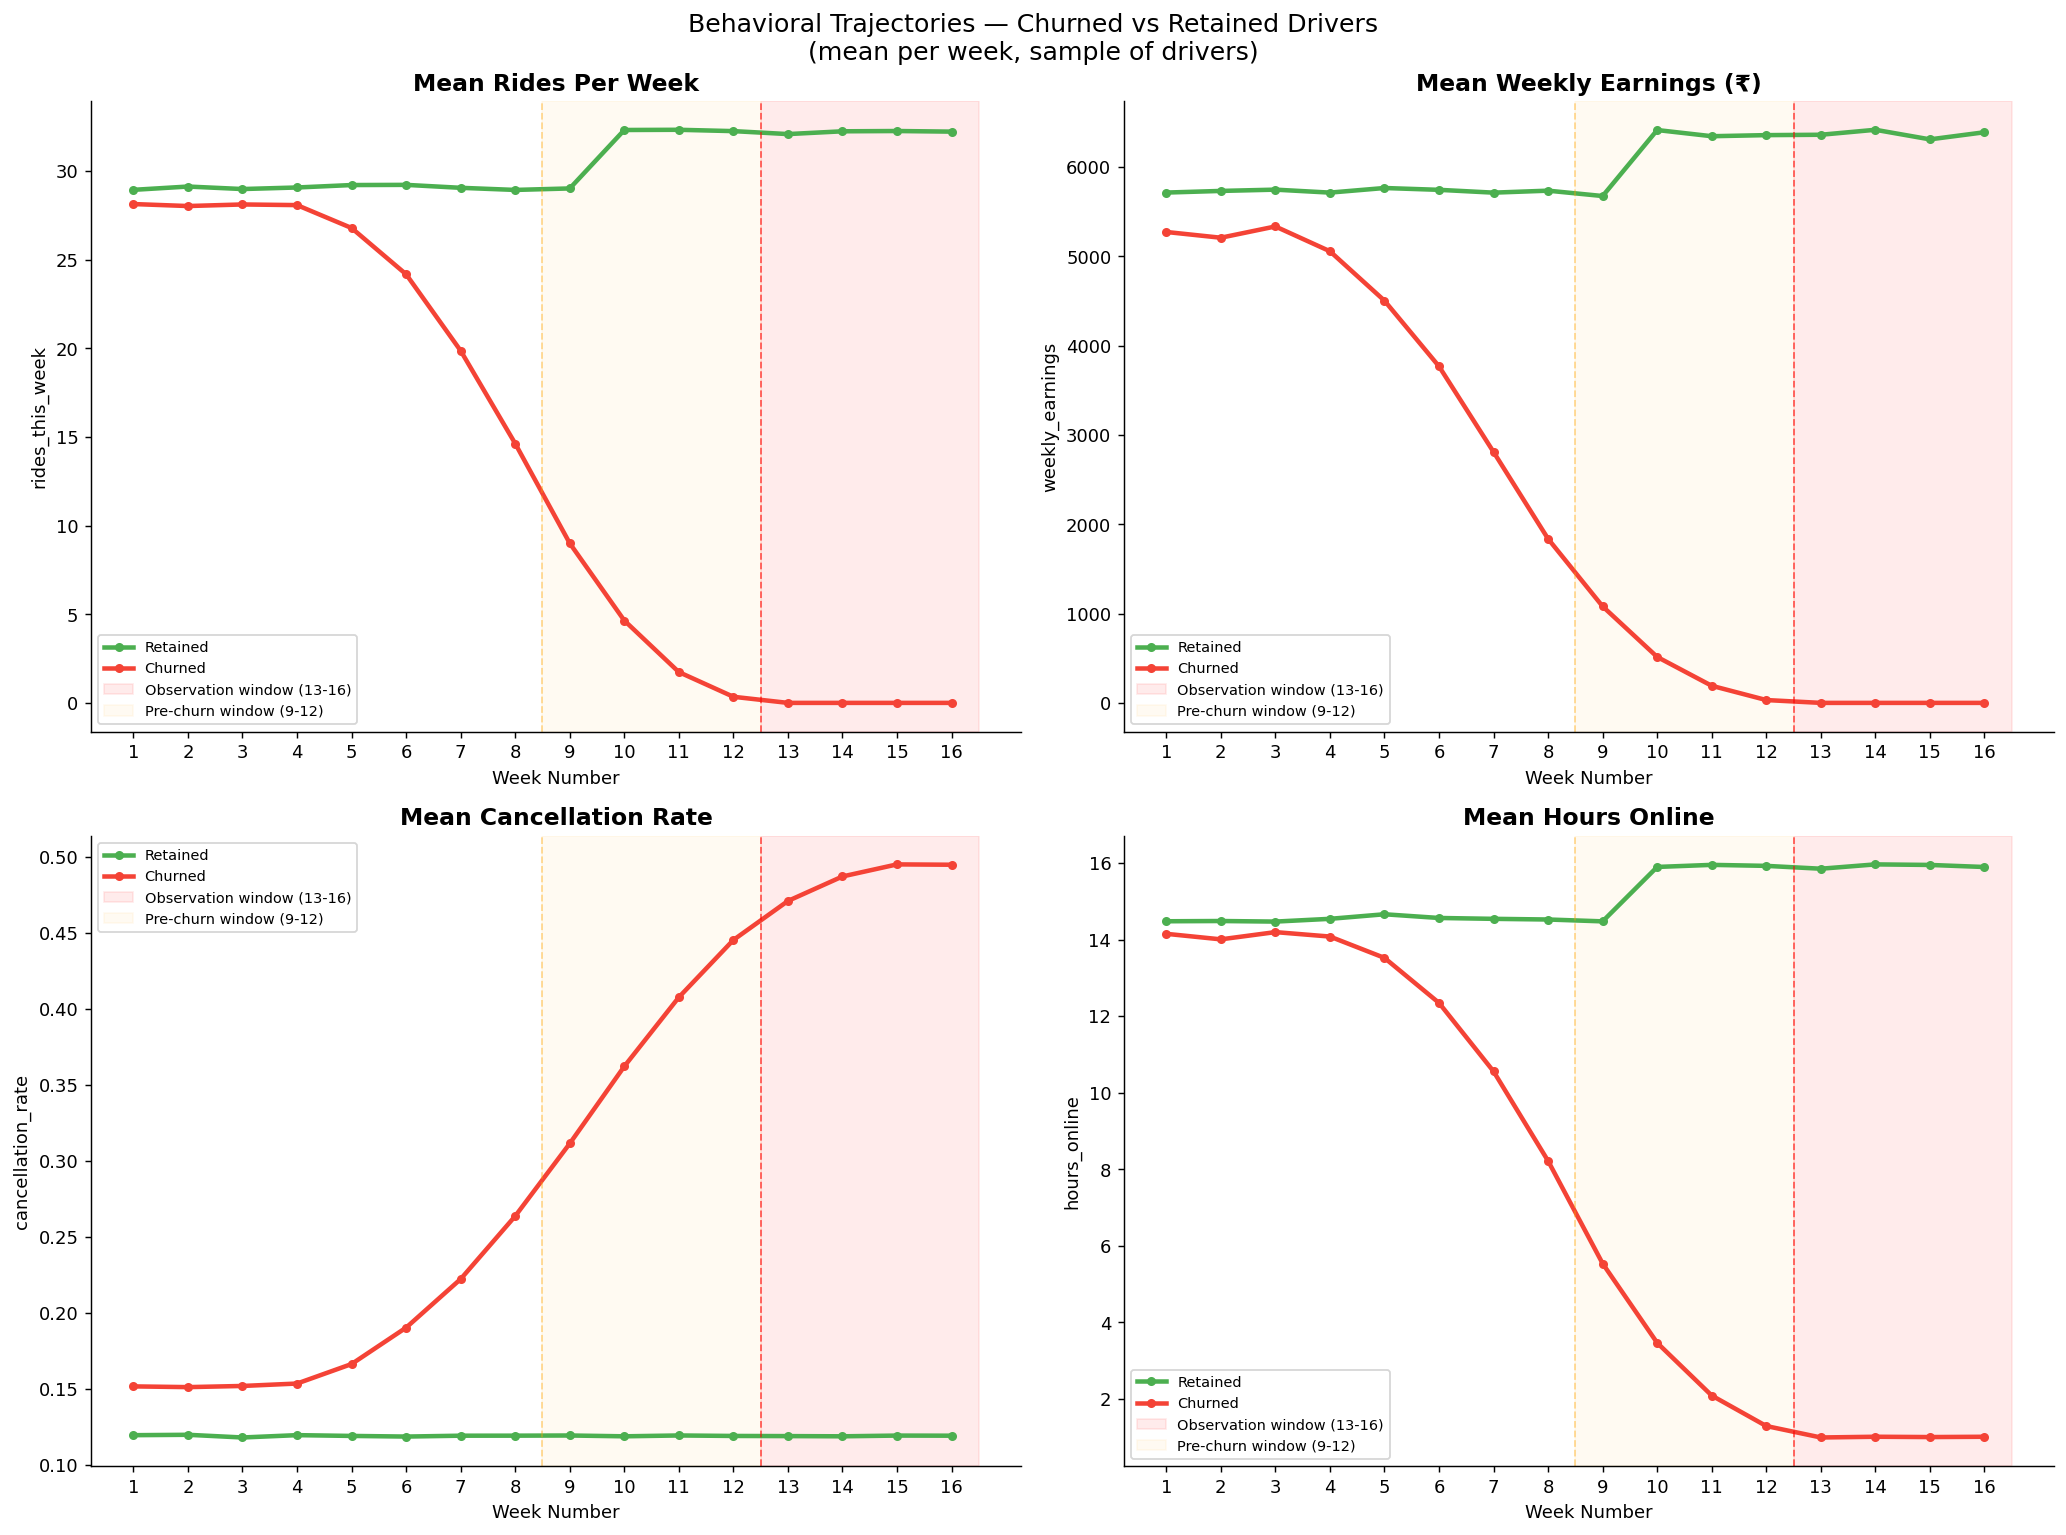

Pre-churn divergence analysis (weeks 9-12 average):

Metric                        Retained      Churned   Difference
-----------------------------------------------------------------
  rides_this_week                31.48         3.93       -87.5%
  weekly_earnings              6199.06       454.56       -92.7%
  cancellation_rate               0.12         0.38      +220.3%
  hours_online                   15.56         3.09       -80.1%


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Behavioral Trajectories — Churned vs Retained Drivers\n"
             "(mean per week, sample of drivers)",
             fontsize=14)

metrics = [
    ("rides_this_week",    "Mean Rides Per Week",     axes[0][0], "#E87722"),
    ("weekly_earnings",    "Mean Weekly Earnings (₹)", axes[0][1], "#2196F3"),
    ("cancellation_rate",  "Mean Cancellation Rate",  axes[1][0], "#F44336"),
    ("hours_online",       "Mean Hours Online",       axes[1][1], "#9C27B0"),
]

for col, title, ax, color in metrics:
    for k in [0, 1]:
        subset = weekly_df[weekly_df["is_churned"] == k]
        mean_by_week = subset.groupby("week_number")[col].mean()

        ax.plot(mean_by_week.index, mean_by_week.values,
                color=CHURN_COLORS[k], linewidth=2.5,
                marker="o", markersize=4,
                label=CHURN_LABELS[k])

    # Shade the observation window
    ax.axvspan(12.5, 16.5, alpha=0.08, color="red",
               label="Observation window (13-16)")
    ax.axvspan(8.5, 12.5, alpha=0.05, color="orange",
               label="Pre-churn window (9-12)")
    ax.axvline(12.5, color="red", linestyle="--",
               linewidth=1, alpha=0.6)
    ax.axvline(8.5, color="orange", linestyle="--",
               linewidth=1, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Week Number")
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
    ax.set_xticks(range(1, 17))

plt.tight_layout()
plt.savefig("../data/processed/eda_02_behavioral_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Quantify the pre-churn divergence
print("Pre-churn divergence analysis (weeks 9-12 average):\n")
print(f"{'Metric':<25} {'Retained':>12} {'Churned':>12} {'Difference':>12}")
print("-" * 65)
for col, title, _, _ in metrics:
    retained_mean = weekly_df[
        (weekly_df["is_churned"]==0) &
        (weekly_df["week_number"].between(9,12))
    ][col].mean()
    churned_mean  = weekly_df[
        (weekly_df["is_churned"]==1) &
        (weekly_df["week_number"].between(9,12))
    ][col].mean()
    diff = churned_mean - retained_mean
    pct  = diff / retained_mean * 100 if retained_mean != 0 else 0
    print(f"  {col:<23} {retained_mean:>12.2f} "
          f"{churned_mean:>12.2f} "
          f"{pct:>+11.1f}%")

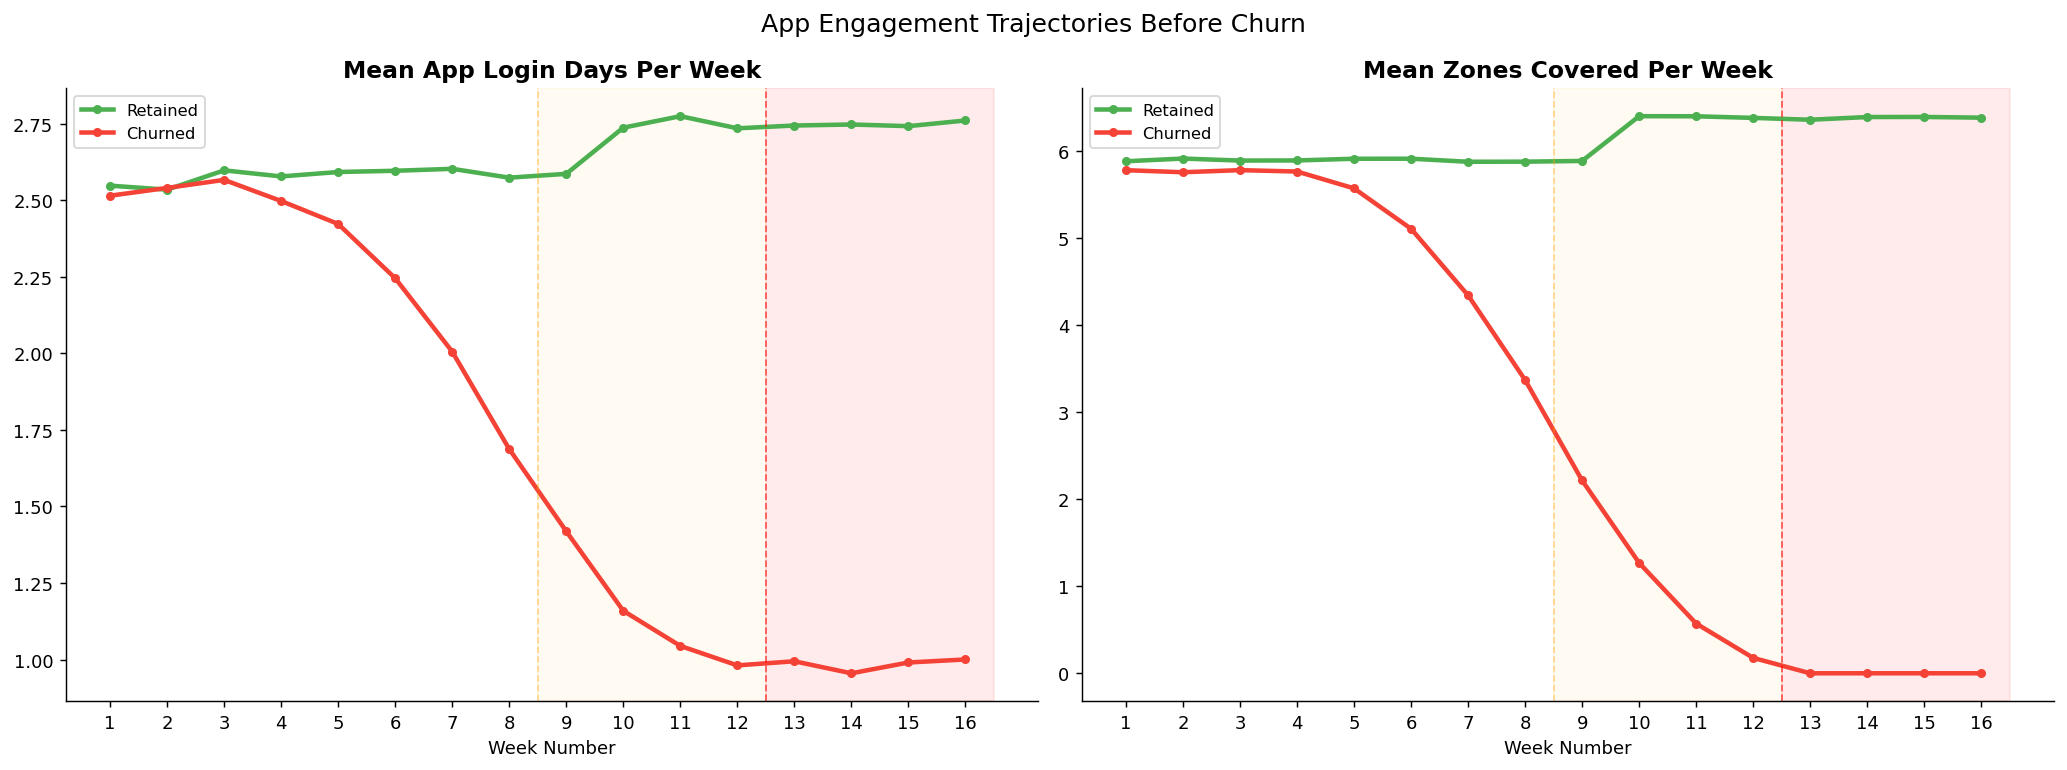

Engagement in final active window (weeks 9-12):
  Retained     login_days: 2.708
  Churned      login_days: 1.151

  Retained     zones_covered: 6.267
  Churned      zones_covered: 1.058



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("App Engagement Trajectories Before Churn", fontsize=14)

engagement_metrics = [
    ("login_days",    "Mean App Login Days Per Week"),
    ("zones_covered", "Mean Zones Covered Per Week"),
]

for idx, (col, title) in enumerate(engagement_metrics):
    for k in [0, 1]:
        subset = weekly_df[weekly_df["is_churned"] == k]
        mean_by_week = subset.groupby("week_number")[col].mean()
        axes[idx].plot(
            mean_by_week.index, mean_by_week.values,
            color=CHURN_COLORS[k], linewidth=2.5,
            marker="o", markersize=4,
            label=CHURN_LABELS[k]
        )
    axes[idx].axvspan(12.5, 16.5, alpha=0.08, color="red")
    axes[idx].axvspan(8.5, 12.5, alpha=0.05, color="orange")
    axes[idx].axvline(12.5, color="red",
                      linestyle="--", linewidth=1, alpha=0.6)
    axes[idx].axvline(8.5, color="orange",
                      linestyle="--", linewidth=1, alpha=0.4)
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Week Number")
    axes[idx].set_xticks(range(1, 17))
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_engagement_trajectories.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Engagement in final active window (weeks 9-12):")
for col, title in engagement_metrics:
    for k in [0, 1]:
        mean_val = weekly_df[
            (weekly_df["is_churned"]==k) &
            (weekly_df["week_number"].between(9,12))
        ][col].mean()
        print(f"  {CHURN_LABELS[k]:<12} {col}: {mean_val:.3f}")
    print()

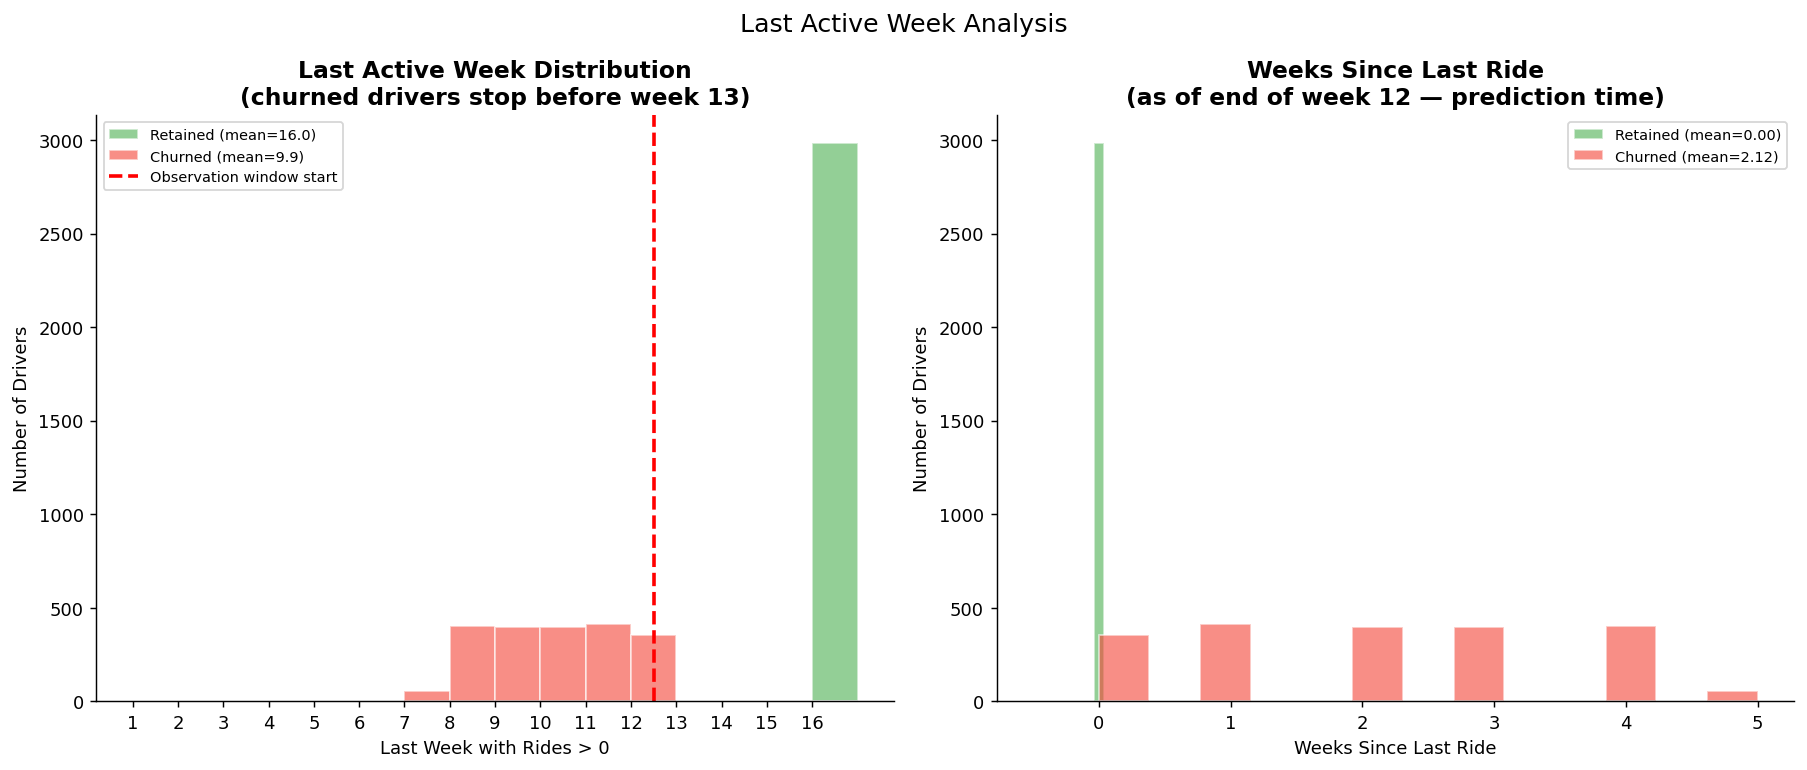

Last active week statistics:
  Retained    : mean=16.00  median=16  min=16  max=16
  Churned     : mean=9.88  median=10  min=7  max=12

Weeks since last ride (as of week 12):
  Retained    : mean=0.000
  Churned     : mean=2.116


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Last Active Week Analysis", fontsize=14)

# For each driver, find the last week they had rides > 0
last_active = weekly_df[
    weekly_df["rides_this_week"] > 0
].groupby("driver_id")["week_number"].max().reset_index()
last_active.columns = ["driver_id", "last_active_week"]
last_active = last_active.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

# Distribution of last active week
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["last_active_week"]
    axes[0].hist(
        subset, bins=16, alpha=0.6,
        color=CHURN_COLORS[k],
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.1f})",
        edgecolor="white", range=(1, 17)
    )

axes[0].axvline(12.5, color="red", linestyle="--",
                linewidth=2, label="Observation window start")
axes[0].set_title("Last Active Week Distribution\n"
                  "(churned drivers stop before week 13)")
axes[0].set_xlabel("Last Week with Rides > 0")
axes[0].set_ylabel("Number of Drivers")
axes[0].set_xticks(range(1, 17))
axes[0].legend(fontsize=8)

# Weeks since last ride — as of week 12 (prediction time)
last_active["weeks_since_last_ride"] = 12 - last_active[
    "last_active_week"
].clip(upper=12)

for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["weeks_since_last_ride"]
    axes[1].hist(
        subset, bins=13, alpha=0.6,
        color=CHURN_COLORS[k],
        label=f"{CHURN_LABELS[k]} (mean={subset.mean():.2f})",
        edgecolor="white"
    )
axes[1].set_title("Weeks Since Last Ride\n"
                  "(as of end of week 12 — prediction time)")
axes[1].set_xlabel("Weeks Since Last Ride")
axes[1].set_ylabel("Number of Drivers")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_04_last_active_week.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Last active week statistics:")
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["last_active_week"]
    print(f"  {CHURN_LABELS[k]:<12}: "
          f"mean={subset.mean():.2f}  "
          f"median={subset.median():.0f}  "
          f"min={subset.min():.0f}  max={subset.max():.0f}")

print("\nWeeks since last ride (as of week 12):")
for k in [0, 1]:
    subset = last_active[
        last_active["is_churned"] == k
    ]["weeks_since_last_ride"]
    print(f"  {CHURN_LABELS[k]:<12}: mean={subset.mean():.3f}")

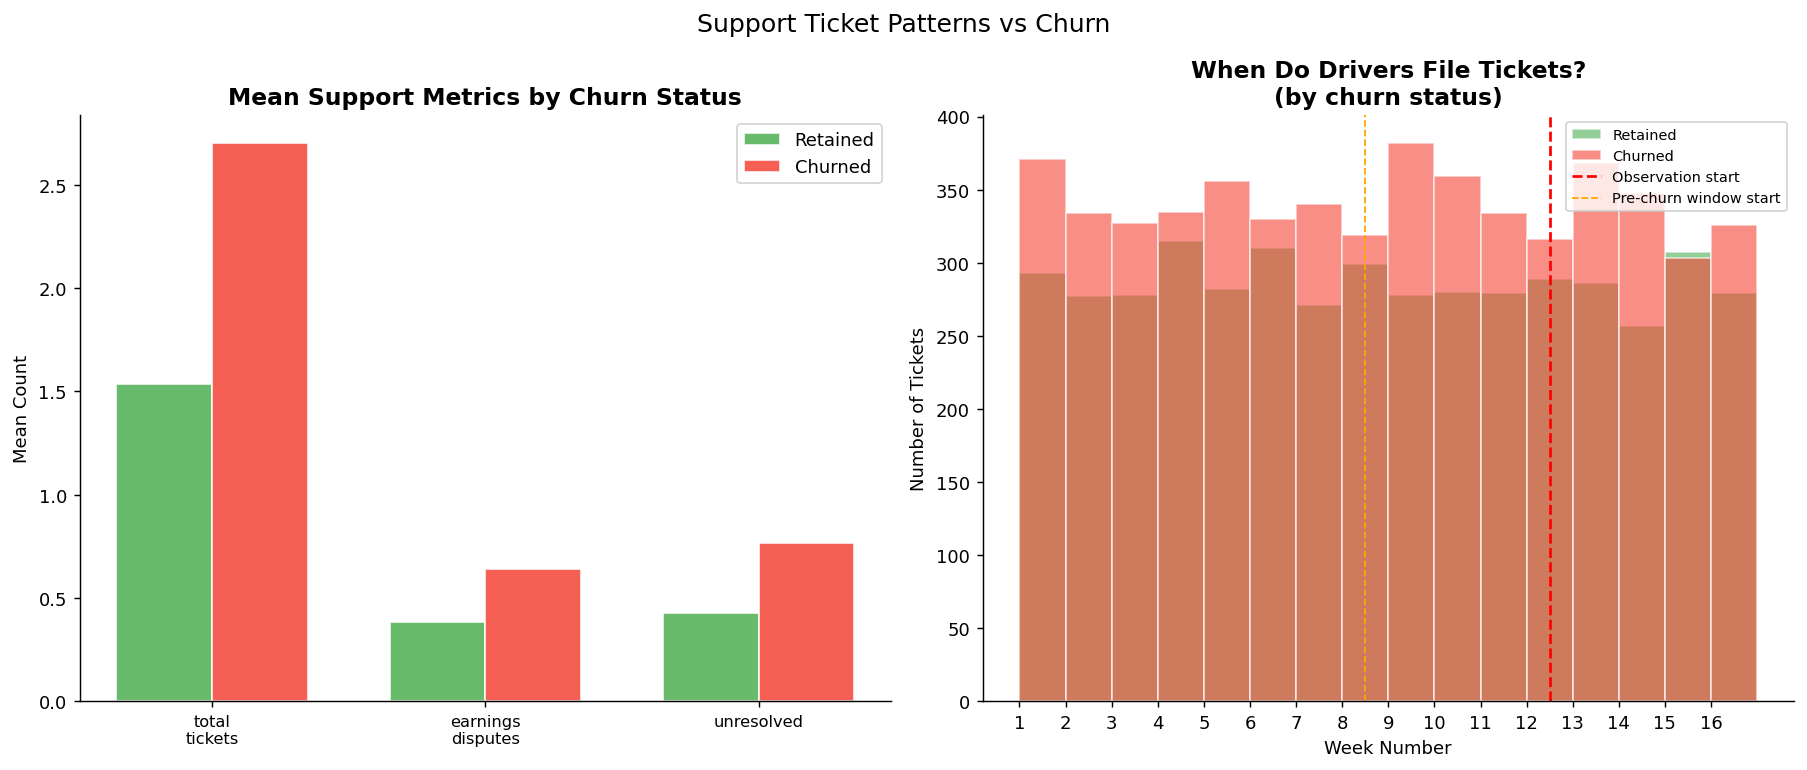

Support ticket comparison:
            total_tickets  earnings_disputes  unresolved
is_churned                                              
0                   1.534              0.386       0.427
1                   2.704              0.638       0.766


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Support Ticket Patterns vs Churn", fontsize=14)

# Ticket count by churn status
ticket_summary = drivers_df.merge(
    tickets_df.groupby("driver_id").agg(
        total_tickets      = ("category", "count"),
        earnings_disputes  = ("category",
            lambda x: (x=="earnings_dispute").sum()),
        unresolved         = ("resolution",
            lambda x: (x=="pending").sum()),
        avg_satisfaction   = ("satisfaction", "mean")
    ).reset_index(),
    on="driver_id", how="left"
).fillna(0)

ticket_cols = [
    "total_tickets", "earnings_disputes", "unresolved"
]
ticket_means = ticket_summary.groupby("is_churned")[
    ticket_cols
].mean()

x = np.arange(len(ticket_cols))
width = 0.35
axes[0].bar(x - width/2,
            [ticket_means.loc[0, c] for c in ticket_cols],
            width, label="Retained",
            color=CHURN_COLORS[0], edgecolor="white", alpha=0.85)
axes[0].bar(x + width/2,
            [ticket_means.loc[1, c] for c in ticket_cols],
            width, label="Churned",
            color=CHURN_COLORS[1], edgecolor="white", alpha=0.85)
axes[0].set_title("Mean Support Metrics by Churn Status")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [c.replace("_","\n") for c in ticket_cols], fontsize=9
)
axes[0].set_ylabel("Mean Count")
axes[0].legend()

# Ticket timing — when do churned drivers file tickets?
churned_ticket_weeks = tickets_df.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

for k in [0, 1]:
    subset = churned_ticket_weeks[
        churned_ticket_weeks["is_churned"] == k
    ]["ticket_week"]
    axes[1].hist(
        subset, bins=16, alpha=0.6,
        color=CHURN_COLORS[k],
        label=CHURN_LABELS[k],
        edgecolor="white", range=(1, 17)
    )
axes[1].axvline(12.5, color="red", linestyle="--",
                linewidth=1.5, label="Observation start")
axes[1].axvline(8.5, color="orange", linestyle="--",
                linewidth=1, label="Pre-churn window start")
axes[1].set_title("When Do Drivers File Tickets?\n"
                  "(by churn status)")
axes[1].set_xlabel("Week Number")
axes[1].set_ylabel("Number of Tickets")
axes[1].set_xticks(range(1, 17))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_05_support_tickets.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Support ticket comparison:")
print(ticket_means.round(3))

RFM FRAMEWORK ANALYSIS

Recency — Frequency — Monetary

The three universal dimensions of customer/driver engagement



LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

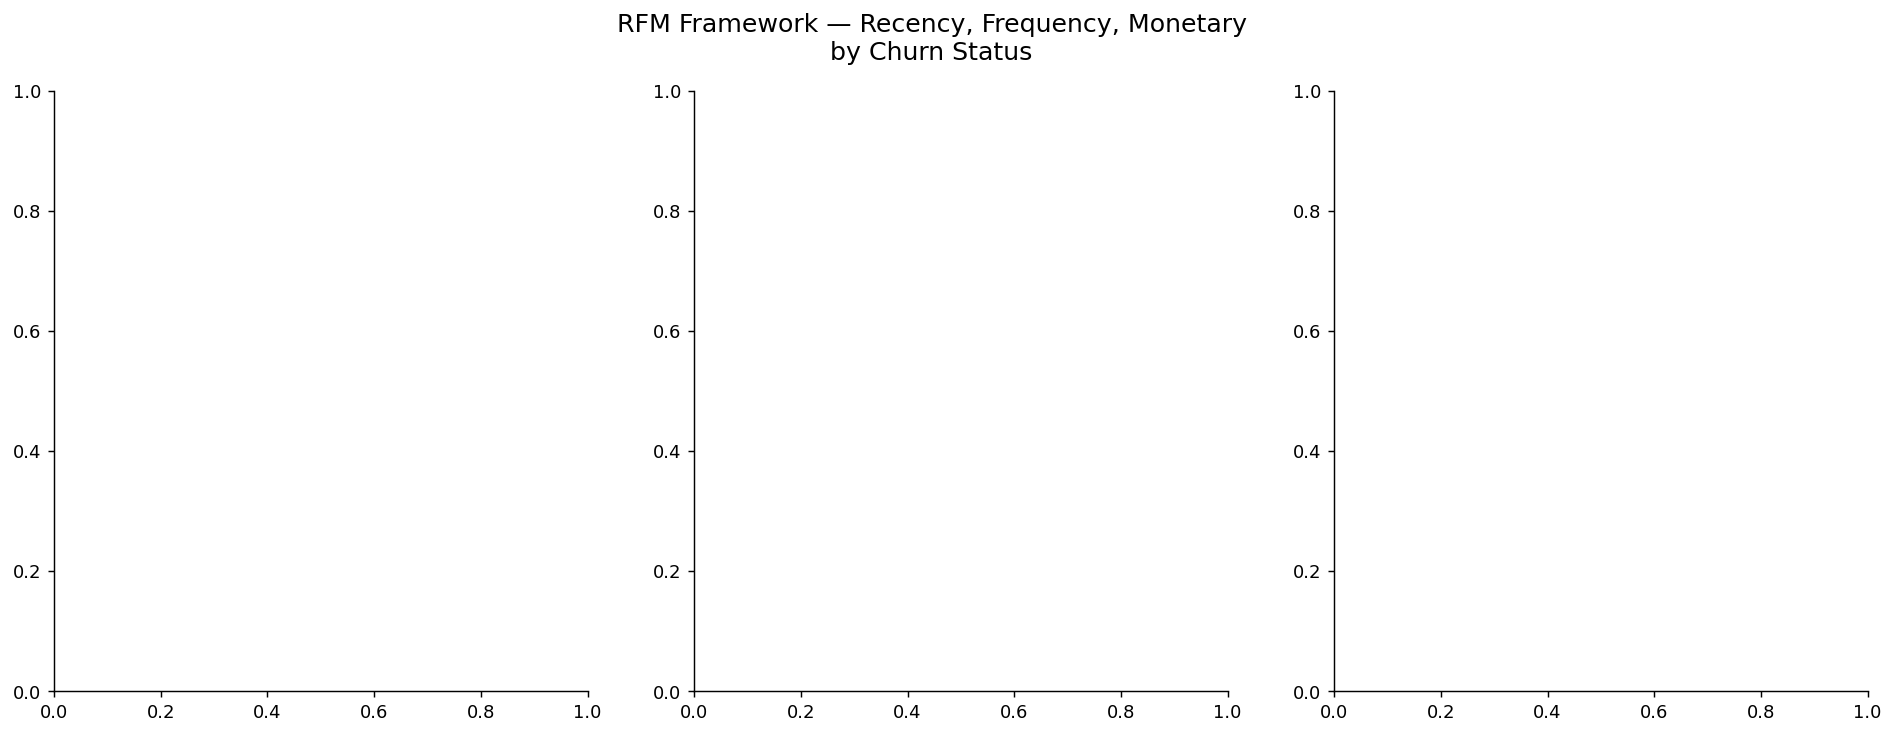

In [ ]:
print("RFM FRAMEWORK ANALYSIS\n")
print("Recency — Frequency — Monetary\n")
print("The three universal dimensions of customer/driver engagement\n")

# Compute RFM for each driver from weeks 1-12
active_weeks = weekly_df[weekly_df["week_number"].between(1, 12)]

rfm = active_weeks.groupby("driver_id").agg(
    # Recency — last week with rides
    last_ride_week    = ("rides_this_week",
        lambda x: x[x > 0].index[-1]
        if any(x > 0) else 0),
    # Frequency — mean rides per week
    mean_rides_week   = ("rides_this_week", "mean"),
    total_rides       = ("rides_this_week", "sum"),
    # Monetary — total earnings
    total_earnings    = ("weekly_earnings", "sum"),
    mean_earnings     = ("weekly_earnings", "mean"),
    # Engagement
    mean_login_days   = ("login_days", "mean"),
).reset_index()

# Fix last_ride_week — it captured index not week_number
# Recompute properly
last_ride = active_weeks[
    active_weeks["rides_this_week"] > 0
].groupby("driver_id")["week_number"].max().reset_index()
last_ride.columns = ["driver_id", "last_ride_week"]

rfm = rfm.drop(columns=["last_ride_week"]).merge(
    last_ride, on="driver_id", how="left"
)
rfm["last_ride_week"] = rfm["last_ride_week"].fillna(0)
rfm["weeks_since_last_ride"] = 12 - rfm["last_ride_week"]

rfm = rfm.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RFM Framework — Recency, Frequency, Monetary\n"
             "by Churn Status", fontsize=14)

rfm_metrics = [
    ("weeks_since_last_ride", "Recency\n(weeks since last ride)", axes[0]),
    ("mean_rides_week",       "Frequency\n(mean rides/week)",     axes[1]),
    ("total_earnings",        "Monetary\n(total earnings ₹)",     axes[2]),
]

for col, title, ax in rfm_metrics:
    for k in [0, 1]:
        subset = rfm[rfm["is_churned"]==k][col].dropna()
        if len(subset) < 2 or subset.nunique() == 1:
            if len(subset) > 0:
                ax.hist(subset, bins=10, density=True,
                        alpha=0.4, color=CHURN_COLORS[k],
                        label=f"{CHURN_LABELS[k]} "
                              f"(mean={subset.mean():.2f})",
                        edgecolor="white")
        else:
            subset.plot.kde(
                ax=ax, color=CHURN_COLORS[k],
                linewidth=2.5,
                label=f"{CHURN_LABELS[k]} "
                      f"(mean={subset.mean():.2f})"
            )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eda_06_rfm_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("RFM Summary by Churn Status:")
print(f"\n{'Metric':<30} {'Retained':>12} {'Churned':>12}")
print("-" * 56)
for col, title, _ in rfm_metrics:
    ret_mean  = rfm[rfm["is_churned"]==0][col].mean()
    churn_mean= rfm[rfm["is_churned"]==1][col].mean()
    print(f"  {col:<28} {ret_mean:>12.2f} {churn_mean:>12.2f}")